# 🎯 Pipeline FPD — Hackathon TMB × PIT

## Melhorias aplicadas em relação ao pipeline original

| # | Melhoria | Justificativa |
|---|----------|---------------|
| 1 | **Remoção rigorosa de leakage** | Regra inegociável: não usar colunas pós-evento (status_cobranca, dias_em_atraso, recebido, etc.). |
| 2 | **Split TEMPORAL (não random)** | PDF lista "random split" como erro que elimina soluções. Treinar no passado, avaliar no futuro. |
| 3 | **Frequency encoding** em produtor/lançamento | Alta cardinalidade — one-hot explodiria a dimensionalidade. |
| 4 | **6 estratégias de balanceamento** | baseline, class_weight, SMOTE, ADASYN, RandomUnderSampler, SMOTEENN |
| 5 | **5 modelos comparados** | LogReg, RandomForest, ExtraTrees, XGBoost, LightGBM |
| 6 | **Métricas profissionais** | ROC-AUC, PR-AUC, **KS** (clássica de crédito), F1, **Recall top-10%/20%** |
| 7 | **Otimização com Optuna** | Tuning bayesiano (TPE) nos top-3 — mais eficiente que GridSearch |
| 8 | **Validação cruzada** durante tuning | StratifiedKFold para estimativas robustas |
| 9 | **Tabela de decis + lift** | Resposta à pergunta da banca: "quanto FPD nos top X%?" |
| 10 | **Submissão no formato oficial** | `pedido_id, prob_fpd, faixa_risco` |

---


## 1️⃣ Imports e configuração

In [5]:
# Instale o que faltar com:
#   pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn optuna matplotlib seaborn scipy openpyxl

import pandas as pd
import numpy as np
import re
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score,
                              confusion_matrix, roc_curve, precision_recall_curve)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from scipy.stats import ks_2samp

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', None)
print('✅ Bibliotecas carregadas')

✅ Bibliotecas carregadas


## 2️⃣ Carregamento dos dados

In [6]:
ARQUIVO = 'basetreinamento.xlsx'
df = pd.read_excel(ARQUIVO, nrows=5000)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (5000, 56)


,pedido_id,CPF,SCORE_HCP4,SCORE_HCP5,SCORE_HEST,SCORE_HFI4,SCORE_HFI5,HI01_PROB,HI01_CONCEITO,SCORE_HIPA,SCORE_HIPN,HPG5,HCR5,H5OR,SCORE_HRM5,SCORE_HSV4,SCORE_HSV5,SCORE_HVA4,SCORE_HVA5,MENSAGEM_TIPO_REGISTRO,FPD,produtor,lancamento,segmento,status_cobranca,status_financeiro,status_pedido,nome,email,score,categoria_risco_score,documento,endereco_cep,endereco_estado,endereco_cidade,nascimento,idade,telefone_ativo,modalidade,total_financiado,quantidade_parcelas,saldo_vencido,quantidade_parcelas_vencidas,recebido,primeiro_vencimento_em_atraso,dias_em_atraso,pdd,saldo_vencido_com_juros,total_pago_com_juros,aguardando_pagamento_sem_juros,vencidos_sem_juros_tmb,recebido_sem_juros_tmb,data_efetivacao,data_quitacao,order_bump,pedido_pai_ob
0,26414,D6CEA19DCA,567,567,1,558,570,NaN,NaN,99,100,NaN,NaN,NaN,NaN,500,538,458,494,APTOS,NÃ£o,Produtor_1583,Lancamento_2563,Autoconhecimento,CobranÃ§a Interna,Inadimplente,Efetivado,Cliente_25AAFE70,user_6DDD6F8B@anon.local,130,Alto,D6CEA19DCA,88220000,Santa Catarina,Cidade_1893,1978-12-12 00:00:00,47,BDECE65488,Compartilhado,1944.22,13.0,743.7,5.0,1200.52,2024-11-20 00:00:00,434,False,743.7,1244.15,NaN,533.25,932.35,2024-08-21 16:48:00,NaT,NaT,NaN
1,60182,BC8B4630C6,580,567,6,679,621,0.099992,0.0,99,94,191.0,88.0,50698.0,1599.0,575,623,673,598,APTOS,NÃ£o,Produtor_0238,Lancamento_2456,Empreendedor,NaN,Adimplente,Cancelamento Solicitado,Cliente_45B91102,user_9612B4E0@anon.local,196,Alto,BC8B4630C6,39540000,MG,Cidade_3985,1981-09-14 00:00:00,44,6F2C9BC475,Compartilhado,129.7,1.0,NaN,0.0,129.70,NaN,NaN,False,NaN,129.70,NaN,NaN,97.28,2024-06-07 00:12:00,NaT,NaT,NaN
2,938745,BC8B4630C6,580,567,6,679,621,0.099992,0.0,99,94,191.0,88.0,50698.0,1599.0,575,623,673,598,APTOS,NÃ£o,Produtor_0181,Lancamento_2660,Empreendedor,NaN,Quitado,Efetivado,Cliente_CF1B01F0,user_9612B4E0@anon.local,710,Baixo,BC8B4630C6,39540-000,MG,Cidade_3985,1981-09-14 00:00:00,44,56C8E4B75C,Antecipado,1796.04,12.0,NaN,0.0,1796.04,NaN,NaN,False,NaN,1820.73,NaN,NaN,1497.00,2024-06-07 21:59:00,2025-07-17 00:15:00,NaT,NaN


## 3️⃣ Limpeza: remoção de leakage

> Regra inegociável do desafio: o modelo deve usar apenas informações disponíveis no momento do checkout.


In [7]:
# 1) Colunas pós-evento — LEAKAGE
LEAKAGE_COLS = [
    'status_cobranca', 'status_financeiro', 'status_pedido',
    'saldo_vencido', 'quantidade_parcelas_vencidas', 'recebido',
    'primeiro_vencimento_em_atraso', 'dias_em_atraso', 'pdd',
    'saldo_vencido_com_juros', 'total_pago_com_juros',
    'aguardando_pagamento_sem_juros', 'vencidos_sem_juros_tmb',
    'recebido_sem_juros_tmb', 'data_quitacao',
]

# 2) Identificadores / PII
ID_COLS = [
    'pedido_id', 'CPF', 'documento', 'documento2', 'nome', 'email',
    'telefone_ativo', 'endereco_cep', 'endereco_cidade', 'pedido_pai_ob',
]

cols_to_drop = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df.columns]
df_clean = df.drop(columns=cols_to_drop).copy()

print(f'🗑️  Removidas {len(cols_to_drop)} colunas: {cols_to_drop}')
print(f'📉 Shape após limpeza: {df_clean.shape}')

🗑️  Removidas 24 colunas: ['status_cobranca', 'status_financeiro', 'status_pedido', 'saldo_vencido', 'quantidade_parcelas_vencidas', 'recebido', 'primeiro_vencimento_em_atraso', 'dias_em_atraso', 'pdd', 'saldo_vencido_com_juros', 'total_pago_com_juros', 'aguardando_pagamento_sem_juros', 'vencidos_sem_juros_tmb', 'recebido_sem_juros_tmb', 'data_quitacao', 'pedido_id', 'CPF', 'documento', 'nome', 'email', 'telefone_ativo', 'endereco_cep', 'endereco_cidade', 'pedido_pai_ob']
📉 Shape após limpeza: (5000, 32)


## 4️⃣ Target FPD

In [8]:
def map_fpd(v):
    s = str(v).strip().lower()
    if 'sim' in s or s == 's' or s == '1':
        return 1
    return 0

df_clean['FPD'] = df['FPD'].apply(map_fpd).astype(int)
print(df_clean['FPD'].value_counts())
print(f'Taxa positiva: {df_clean["FPD"].mean():.2%}')

FPD
0    4203
1     797
Name: count, dtype: int64
Taxa positiva: 15.94%


## 5️⃣ Feature engineering

- `idade`: alguns vêm como número, outros como data → padronizar
- `data_efetivacao`: extrair mês/dia/dow + manter para split temporal
- `produtor`, `lancamento`: alta cardinalidade → **frequency encoding**
- Categóricas com poucas classes → one-hot com `dummy_na=True`


In [9]:
hoje = datetime.today()

def fix_idade(v):
    if pd.isna(v): return np.nan
    if isinstance(v, (int, float)): return float(v)
    if isinstance(v, (datetime, pd.Timestamp)):
        return (hoje - v).days // 365
    return np.nan
df_clean['idade'] = df_clean['idade'].apply(fix_idade)

if 'nascimento' in df_clean.columns:
    nasc = pd.to_datetime(df_clean['nascimento'], errors='coerce')
    df_clean['idade'] = df_clean['idade'].fillna((hoje - nasc).dt.days // 365)
    df_clean = df_clean.drop(columns=['nascimento'])

df_clean['data_efetivacao'] = pd.to_datetime(df_clean['data_efetivacao'], errors='coerce')
df_clean['ef_mes'] = df_clean['data_efetivacao'].dt.month
df_clean['ef_dow'] = df_clean['data_efetivacao'].dt.dayofweek
df_clean['ef_dia'] = df_clean['data_efetivacao'].dt.day
df_clean['ef_ano'] = df_clean['data_efetivacao'].dt.year

for c in ['total_financiado', 'quantidade_parcelas', 'score']:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

if 'categoria_risco_score' in df_clean.columns:
    df_clean = df_clean.drop(columns=['categoria_risco_score'])

if 'endereco_estado' in df_clean.columns:
    df_clean['endereco_estado'] = (df_clean['endereco_estado']
        .astype(str).str.strip().str.upper().str[:2])

# frequency encoding
for col in ['produtor', 'lancamento']:
    if col in df_clean.columns:
        freq = df_clean[col].value_counts(normalize=True)
        df_clean[col + '_freq'] = df_clean[col].map(freq)
        df_clean = df_clean.drop(columns=[col])

cat_cols = [c for c in ['segmento', 'modalidade', 'MENSAGEM_TIPO_REGISTRO',
                          'endereco_estado', 'order_bump'] if c in df_clean.columns]
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dummy_na=True)

df_clean.columns = [re.sub(r'[^\w]', '_', c) for c in df_clean.columns]

obj_cols = df_clean.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f'⚠️  Removendo objects não tratados: {obj_cols}')
    df_clean = df_clean.drop(columns=obj_cols)

print(f'✅ Shape final: {df_clean.shape}')

✅ Shape final: (5000, 78)


## 6️⃣ Split TEMPORAL (não random!)

> Random split em problema de crédito **superestima** a métrica e está listado como erro grave no PDF.

- **80% mais antigos** → treino
- **20% mais recentes** → teste (simula o futuro)


In [10]:
df_clean = df_clean.sort_values('data_efetivacao').reset_index(drop=True)
corte = int(len(df_clean) * 0.8)

print(f'📅 Treino: {df_clean["data_efetivacao"].iloc[:corte].min()} → {df_clean["data_efetivacao"].iloc[:corte].max()}')
print(f'📅 Teste:  {df_clean["data_efetivacao"].iloc[corte:].min()} → {df_clean["data_efetivacao"].iloc[corte:].max()}')

train_df = df_clean.iloc[:corte].drop(columns=['data_efetivacao'])
test_df  = df_clean.iloc[corte:].drop(columns=['data_efetivacao'])

y_train = train_df['FPD'].astype(int); X_train = train_df.drop(columns=['FPD'])
y_test  = test_df['FPD'].astype(int);  X_test  = test_df.drop(columns=['FPD'])

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns)

print(f'\nX_train: {X_train.shape}, taxa FPD: {y_train.mean():.2%}')
print(f'X_test:  {X_test.shape}, taxa FPD: {y_test.mean():.2%}')

📅 Treino: 1970-01-01 00:00:00.000000208 → 2024-03-21 22:51:00
📅 Teste:  2024-03-22 00:09:00 → 2025-07-31 11:58:00

X_train: (4000, 76), taxa FPD: 17.20%
X_test:  (1000, 76), taxa FPD: 10.90%


## 7️⃣ Funções de avaliação

| Métrica | Por que importa |
|---|---|
| **ROC-AUC** | Ranqueamento; métrica oficial do hackathon |
| **PR-AUC** | Melhor que ROC quando a classe positiva é rara |
| **KS** | Clássica em crédito: separação entre bons e maus |
| **F1** | Balanço precisão/recall no threshold default |
| **Recall top-10%/20%** | Responde "quanto FPD capturo nos N% piores?" |


In [11]:
def ks_statistic(y_true, y_proba):
    return ks_2samp(y_proba[y_true == 1], y_proba[y_true == 0]).statistic

def top_q_recall(y_true, y_proba, q=0.10):
    n_top = max(int(len(y_proba) * q), 1)
    idx_top = np.argsort(-y_proba)[:n_top]
    return y_true.iloc[idx_top].sum() / max(y_true.sum(), 1)

def evaluate_model(model, X_te, y_te, threshold=0.5):
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        'ROC_AUC': roc_auc_score(y_te, proba),
        'PR_AUC':  average_precision_score(y_te, proba),
        'KS':      ks_statistic(y_te.values, proba),
        'F1':      f1_score(y_te, pred),
        'Precision': precision_score(y_te, pred, zero_division=0),
        'Recall':  recall_score(y_te, pred),
        'Top10%':  top_q_recall(y_te, proba, 0.10),
        'Top20%':  top_q_recall(y_te, proba, 0.20),
    }

## 8️⃣ Estratégias de balanceamento

⚠️ **Resampling SÓ no treino. Nunca no teste.**

| Estratégia | Quando usar |
|---|---|
| baseline | sem tratamento; referência |
| class_weight | barato e eficaz; mantém tamanho dos dados |
| SMOTE | oversampling sintético via k-NN |
| ADASYN | foca em pontos difíceis da fronteira |
| RandomUnderSampler | reduz a maioria; rápido mas perde dados |
| SMOTEENN | oversampling + limpeza de ruído |


In [12]:
def get_resampled(strategy, X, y, seed=SEED):
    if strategy in ('baseline', 'class_weight'):
        return X, y
    if strategy == 'SMOTE':
        return SMOTE(random_state=seed, k_neighbors=5).fit_resample(X, y)
    if strategy == 'ADASYN':
        return ADASYN(random_state=seed, n_neighbors=5).fit_resample(X, y)
    if strategy == 'UnderSample':
        return RandomUnderSampler(random_state=seed).fit_resample(X, y)
    if strategy == 'SMOTEENN':
        return SMOTEENN(random_state=seed).fit_resample(X, y)
    raise ValueError(strategy)

STRATEGIES = ['baseline', 'class_weight', 'SMOTE', 'ADASYN', 'UnderSample', 'SMOTEENN']
print('Estratégias:', STRATEGIES)

Estratégias: ['baseline', 'class_weight', 'SMOTE', 'ADASYN', 'UnderSample', 'SMOTEENN']


## 9️⃣ Configuração dos modelos

In [13]:
def build_models(use_class_weight=False):
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    return {
        'LogReg':       LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1,
                                          class_weight='balanced' if use_class_weight else None),
        'RandomForest': RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                              class_weight='balanced' if use_class_weight else None),
        'ExtraTrees':   ExtraTreesClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                            class_weight='balanced' if use_class_weight else None),
        'XGBoost':      XGBClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                      use_label_encoder=False, eval_metric='auc',
                                      scale_pos_weight=scale_pos_weight if use_class_weight else 1),
        'LightGBM':     LGBMClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, verbose=-1,
                                       class_weight='balanced' if use_class_weight else None),
    }

print('Modelos:', list(build_models().keys()))

Modelos: ['LogReg', 'RandomForest', 'ExtraTrees', 'XGBoost', 'LightGBM']


## 🔟 Grid de experimentos: **6 estratégias × 5 modelos = 30 combinações**

LogReg precisa de features padronizadas; modelos de árvore não.


In [14]:
scaler_global = StandardScaler()
X_train_sc = pd.DataFrame(scaler_global.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler_global.transform(X_test),  columns=X_test.columns)

results = []

for strat in STRATEGIES:
    use_cw = (strat == 'class_weight')
    X_tr_r, y_tr_r = get_resampled(strat, X_train, y_train)
    
    print(f'\n--- {strat} | n={len(X_tr_r)} | pos={int((y_tr_r==1).sum())} ---')
    
    for mname, model in build_models(use_class_weight=use_cw).items():
        try:
            if mname == 'LogReg':
                if strat in ('baseline', 'class_weight'):
                    X_tr_use, X_te_use = X_train_sc, X_test_sc
                    y_tr_use = y_train
                else:
                    sc = StandardScaler()
                    X_tr_use = pd.DataFrame(sc.fit_transform(X_tr_r), columns=X_tr_r.columns)
                    X_te_use = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)
                    y_tr_use = y_tr_r
                model.fit(X_tr_use, y_tr_use)
                metrics = evaluate_model(model, X_te_use, y_test)
            else:
                model.fit(X_tr_r, y_tr_r)
                metrics = evaluate_model(model, X_test, y_test)
            
            results.append({'modelo': mname, 'balanceamento': strat, **metrics})
            print(f'  {mname:14s} ROC={metrics["ROC_AUC"]:.3f}  KS={metrics["KS"]:.3f}  F1={metrics["F1"]:.3f}  Top10%={metrics["Top10%"]:.3f}')
        except Exception as e:
            print(f'  {mname:14s} FALHOU: {e}')

df_results = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
df_results.round(4)


--- baseline | n=4000 | pos=688 ---
  LogReg         ROC=0.734  KS=0.393  F1=0.000  Top10%=0.229
  RandomForest   ROC=0.768  KS=0.417  F1=0.068  Top10%=0.330
  ExtraTrees     ROC=0.753  KS=0.392  F1=0.017  Top10%=0.275
  XGBoost        ROC=0.753  KS=0.370  F1=0.200  Top10%=0.321
  LightGBM       ROC=0.761  KS=0.411  F1=0.211  Top10%=0.321

--- class_weight | n=4000 | pos=688 ---
  LogReg         ROC=0.731  KS=0.384  F1=0.240  Top10%=0.239
  RandomForest   ROC=0.793  KS=0.444  F1=0.018  Top10%=0.339
  ExtraTrees     ROC=0.764  KS=0.433  F1=0.035  Top10%=0.248
  XGBoost        ROC=0.733  KS=0.357  F1=0.276  Top10%=0.303
  LightGBM       ROC=0.756  KS=0.405  F1=0.270  Top10%=0.312

--- SMOTE | n=6624 | pos=3312 ---
  LogReg         ROC=0.742  KS=0.406  F1=0.309  Top10%=0.266
  RandomForest   ROC=0.802  KS=0.466  F1=0.123  Top10%=0.330
  ExtraTrees     ROC=0.779  KS=0.443  F1=0.133  Top10%=0.266
  XGBoost        ROC=0.748  KS=0.406  F1=0.230  Top10%=0.294
  LightGBM       ROC=0.759  KS=0.

,modelo,balanceamento,ROC_AUC,PR_AUC,KS,F1,Precision,Recall,Top10%,Top20%
0,RandomForest,SMOTEENN,0.8168,0.3372,0.5134,0.4134,0.3091,0.6239,0.3486,0.5963
1,LightGBM,SMOTEENN,0.8073,0.3145,0.5167,0.3896,0.3015,0.5505,0.3028,0.5505
2,RandomForest,ADASYN,0.8051,0.3101,0.4848,0.1314,0.3214,0.0826,0.3303,0.5505
3,RandomForest,SMOTE,0.8021,0.3261,0.4659,0.1231,0.3810,0.0734,0.3303,0.5688
4,XGBoost,SMOTEENN,0.8011,0.3042,0.4779,0.3974,0.3109,0.5505,0.3211,0.5780
5,ExtraTrees,SMOTEENN,0.7945,0.2929,0.5021,0.3867,0.2883,0.5872,0.2936,0.5321
6,RandomForest,class_weight,0.7931,0.3424,0.4439,0.0179,0.3333,0.0092,0.3394,0.5596
7,RandomForest,UnderSample,0.7929,0.3105,0.4772,0.3632,0.2491,0.6697,0.3486,0.5321
8,ExtraTrees,SMOTE,0.7790,0.2827,0.4426,0.1333,0.3462,0.0826,0.2661,0.4862
9,LightGBM,ADASYN,0.7759,0.2704,0.4518,0.1203,0.3333,0.0734,0.3303,0.5046


## 1️⃣1️⃣ Visualização comparativa

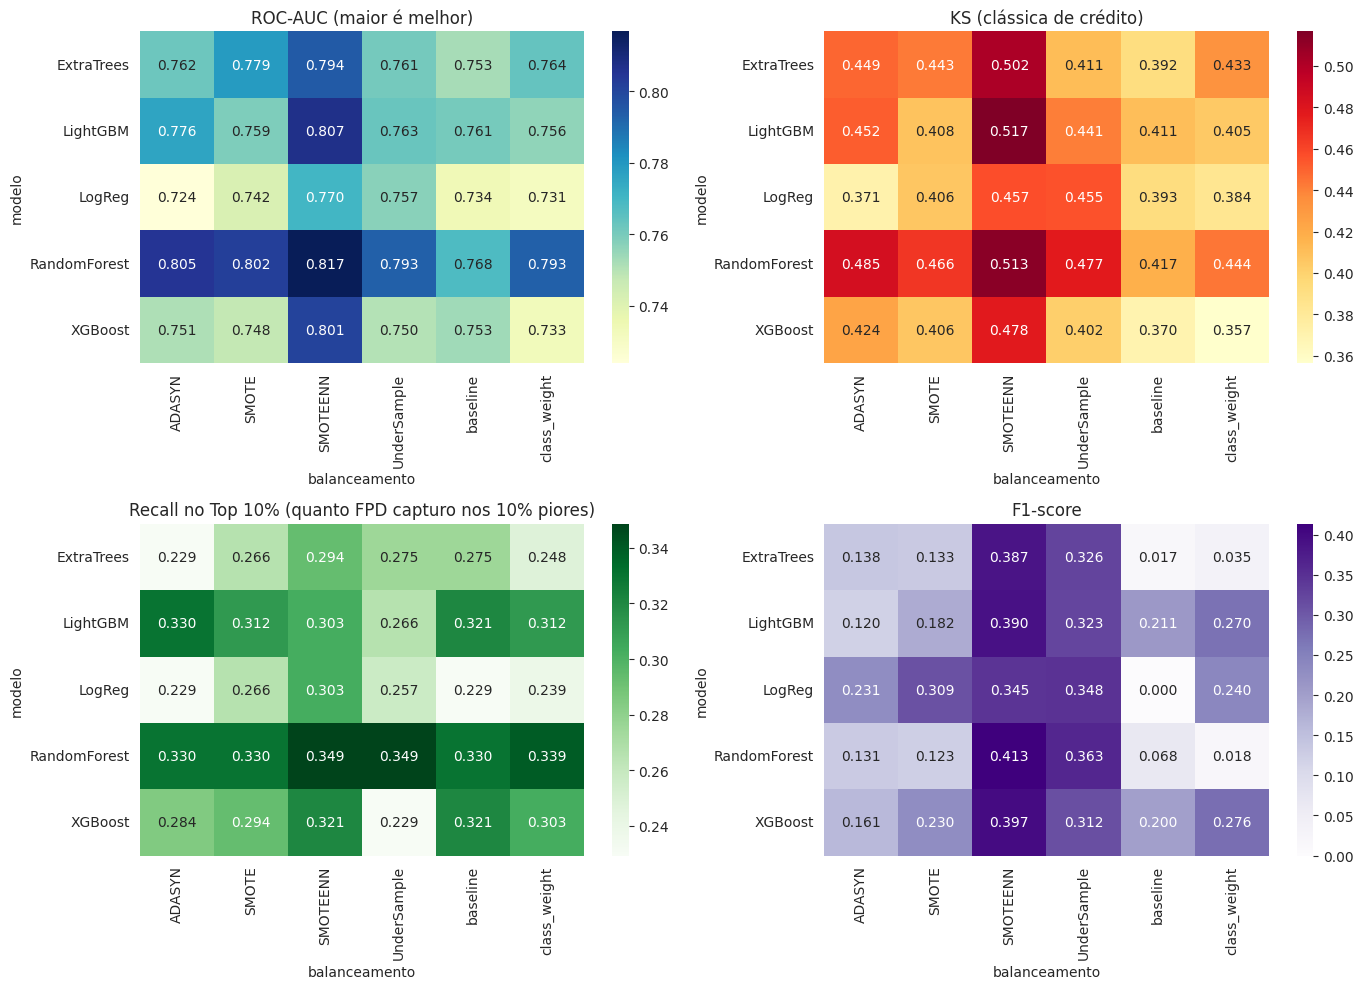

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pivot_roc = df_results.pivot(index='modelo', columns='balanceamento', values='ROC_AUC')
sns.heatmap(pivot_roc, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0,0])
axes[0,0].set_title('ROC-AUC (maior é melhor)')

pivot_ks = df_results.pivot(index='modelo', columns='balanceamento', values='KS')
sns.heatmap(pivot_ks, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0,1])
axes[0,1].set_title('KS (clássica de crédito)')

pivot_top = df_results.pivot(index='modelo', columns='balanceamento', values='Top10%')
sns.heatmap(pivot_top, annot=True, fmt='.3f', cmap='Greens', ax=axes[1,0])
axes[1,0].set_title('Recall no Top 10% (quanto FPD capturo nos 10% piores)')

pivot_f1 = df_results.pivot(index='modelo', columns='balanceamento', values='F1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Purples', ax=axes[1,1])
axes[1,1].set_title('F1-score')

plt.tight_layout()
plt.show()

## 1️⃣2️⃣ Top-3 combinações para tuning

In [16]:
top3 = df_results.head(3).reset_index(drop=True)
print('🏆 TOP 3 combinações que irão para tuning:')
top3[['modelo','balanceamento','ROC_AUC','PR_AUC','KS','F1','Top10%']]

🏆 TOP 3 combinações que irão para tuning:


,modelo,balanceamento,ROC_AUC,PR_AUC,KS,F1,Top10%
0,RandomForest,SMOTEENN,0.816823,0.337163,0.513432,0.413374,0.348624
1,LightGBM,SMOTEENN,0.807267,0.314533,0.516655,0.389610,0.302752
2,RandomForest,ADASYN,0.805131,0.310075,0.484838,0.131387,0.330275


## 1️⃣3️⃣ Otimização de hiperparâmetros com Optuna

- **TPE Sampler** (busca bayesiana, mais eficiente que GridSearch)
- **30 trials** por modelo (ajuste para 50–100 se tiver tempo)
- **3-fold StratifiedKFold** no treino — resampling SÓ no fold de treino
- Objetivo: **maximizar ROC-AUC**


In [17]:
def cv_score(params, model_name, strat, X, y, n_splits=3):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_tr_r, y_tr_r = get_resampled(strat, X_tr, y_tr)
        use_cw = (strat == 'class_weight')
        
        if model_name == 'XGBoost':
            spw = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
            m = XGBClassifier(**params, random_state=SEED, n_jobs=-1,
                              use_label_encoder=False, eval_metric='auc',
                              scale_pos_weight=spw if use_cw else 1)
        elif model_name == 'LightGBM':
            m = LGBMClassifier(**params, random_state=SEED, n_jobs=-1, verbose=-1,
                               class_weight='balanced' if use_cw else None)
        elif model_name == 'RandomForest':
            m = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1,
                                       class_weight='balanced' if use_cw else None)
        elif model_name == 'ExtraTrees':
            m = ExtraTreesClassifier(**params, random_state=SEED, n_jobs=-1,
                                     class_weight='balanced' if use_cw else None)
        elif model_name == 'LogReg':
            sc = StandardScaler()
            X_tr_r = pd.DataFrame(sc.fit_transform(X_tr_r), columns=X_tr_r.columns)
            X_va = pd.DataFrame(sc.transform(X_va), columns=X_va.columns)
            m = LogisticRegression(**params, max_iter=3000, random_state=SEED, n_jobs=-1,
                                   class_weight='balanced' if use_cw else None)
        
        m.fit(X_tr_r, y_tr_r)
        scores.append(roc_auc_score(y_va, m.predict_proba(X_va)[:, 1]))
    return np.mean(scores)

def make_objective(model_name, strat, X, y):
    def objective(trial):
        if model_name == 'XGBoost':
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 100, 600),
                max_depth=trial.suggest_int('max_depth', 3, 10),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                min_child_weight=trial.suggest_int('min_child_weight', 1, 20),
            )
        elif model_name == 'LightGBM':
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 100, 600),
                num_leaves=trial.suggest_int('num_leaves', 15, 200),
                max_depth=trial.suggest_int('max_depth', 3, 12),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                min_child_samples=trial.suggest_int('min_child_samples', 5, 100),
            )
        elif model_name in ('RandomForest', 'ExtraTrees'):
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 100, 600),
                max_depth=trial.suggest_int('max_depth', 4, 25),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20),
                max_features=trial.suggest_categorical('max_features', ['sqrt','log2', 0.5]),
            )
        elif model_name == 'LogReg':
            params = dict(
                C=trial.suggest_float('C', 1e-3, 100, log=True),
                penalty=trial.suggest_categorical('penalty', ['l1','l2']),
                solver='liblinear',
            )
        return cv_score(params, model_name, strat, X, y)
    return objective

tuning_results = []
best_models = {}
N_TRIALS = 30

for i, row in top3.iterrows():
    mname, strat = row['modelo'], row['balanceamento']
    print(f'\n=== TUNING {i+1}/3: {mname} + {strat} ===')
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(make_objective(mname, strat, X_train, y_train),
                   n_trials=N_TRIALS, show_progress_bar=False)
    
    best_params = study.best_params
    print(f'  CV ROC-AUC: {study.best_value:.4f}')
    print(f'  params: {best_params}')
    
    X_tr_r, y_tr_r = get_resampled(strat, X_train, y_train)
    use_cw = (strat == 'class_weight')
    
    if mname == 'XGBoost':
        spw = (y_train==0).sum() / max((y_train==1).sum(), 1)
        final = XGBClassifier(**best_params, random_state=SEED, n_jobs=-1,
                              use_label_encoder=False, eval_metric='auc',
                              scale_pos_weight=spw if use_cw else 1)
    elif mname == 'LightGBM':
        final = LGBMClassifier(**best_params, random_state=SEED, n_jobs=-1, verbose=-1,
                               class_weight='balanced' if use_cw else None)
    elif mname == 'RandomForest':
        final = RandomForestClassifier(**best_params, random_state=SEED, n_jobs=-1,
                                       class_weight='balanced' if use_cw else None)
    elif mname == 'ExtraTrees':
        final = ExtraTreesClassifier(**best_params, random_state=SEED, n_jobs=-1,
                                     class_weight='balanced' if use_cw else None)
    elif mname == 'LogReg':
        sc_final = StandardScaler()
        X_tr_r = pd.DataFrame(sc_final.fit_transform(X_tr_r), columns=X_tr_r.columns)
        X_te_use = pd.DataFrame(sc_final.transform(X_test), columns=X_test.columns)
        final = LogisticRegression(**best_params, max_iter=3000, random_state=SEED, n_jobs=-1,
                                   class_weight='balanced' if use_cw else None)
    
    if mname == 'LogReg':
        final.fit(X_tr_r, y_tr_r)
        metrics_final = evaluate_model(final, X_te_use, y_test)
    else:
        final.fit(X_tr_r, y_tr_r)
        metrics_final = evaluate_model(final, X_test, y_test)
    
    tuning_results.append({
        'modelo': mname, 'balanceamento': strat,
        'cv_best_auc': study.best_value,
        **metrics_final,
        'best_params': best_params
    })
    best_models[f'{mname}_{strat}'] = final

df_tuned = pd.DataFrame(tuning_results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
print('\n🏆 RESULTADO PÓS-TUNING:')
df_tuned[['modelo','balanceamento','cv_best_auc','ROC_AUC','PR_AUC','KS','F1','Top10%']]


=== TUNING 1/3: RandomForest + SMOTEENN ===
  CV ROC-AUC: 0.7432
  params: {'n_estimators': 494, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2'}

=== TUNING 2/3: LightGBM + SMOTEENN ===
  CV ROC-AUC: 0.7531
  params: {'n_estimators': 541, 'num_leaves': 32, 'max_depth': 6, 'learning_rate': 0.03497084750219483, 'subsample': 0.7891912534875793, 'colsample_bytree': 0.8492586140409865, 'reg_alpha': 0.00111145219260857, 'reg_lambda': 0.48616380672607257, 'min_child_samples': 13}

=== TUNING 3/3: RandomForest + ADASYN ===
  CV ROC-AUC: 0.7409
  params: {'n_estimators': 236, 'max_depth': 23, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2'}

🏆 RESULTADO PÓS-TUNING:


,modelo,balanceamento,cv_best_auc,ROC_AUC,PR_AUC,KS,F1,Top10%
0,RandomForest,SMOTEENN,0.743175,0.819376,0.337271,0.517777,0.404145,0.330275
1,RandomForest,ADASYN,0.740918,0.810851,0.314914,0.495135,0.214765,0.311927
2,LightGBM,SMOTEENN,0.753107,0.806485,0.305230,0.491912,0.403909,0.321101


## 1️⃣4️⃣ Antes vs depois do tuning

In [18]:
comp = top3[['modelo','balanceamento','ROC_AUC','KS','F1']].rename(
    columns={'ROC_AUC':'ROC_antes', 'KS':'KS_antes', 'F1':'F1_antes'}
).merge(
    df_tuned[['modelo','balanceamento','ROC_AUC','KS','F1']].rename(
        columns={'ROC_AUC':'ROC_depois', 'KS':'KS_depois', 'F1':'F1_depois'}
    ),
    on=['modelo','balanceamento']
)
comp['ΔROC'] = (comp['ROC_depois'] - comp['ROC_antes']).round(4)
comp['ΔKS']  = (comp['KS_depois'] - comp['KS_antes']).round(4)
comp

,modelo,balanceamento,ROC_antes,KS_antes,F1_antes,ROC_depois,KS_depois,F1_depois,ΔROC,ΔKS
0,RandomForest,SMOTEENN,0.816823,0.513432,0.413374,0.819376,0.517777,0.404145,0.0026,0.0043
1,LightGBM,SMOTEENN,0.807267,0.516655,0.389610,0.806485,0.491912,0.403909,-0.0008,-0.0247
2,RandomForest,ADASYN,0.805131,0.484838,0.131387,0.810851,0.495135,0.214765,0.0057,0.0103


## 1️⃣5️⃣ Modelo campeão: análise detalhada

🏆 Campeão: RandomForest_SMOTEENN
   ROC-AUC: 0.8194
   KS:      0.5178
   Top 10%: 33.03%


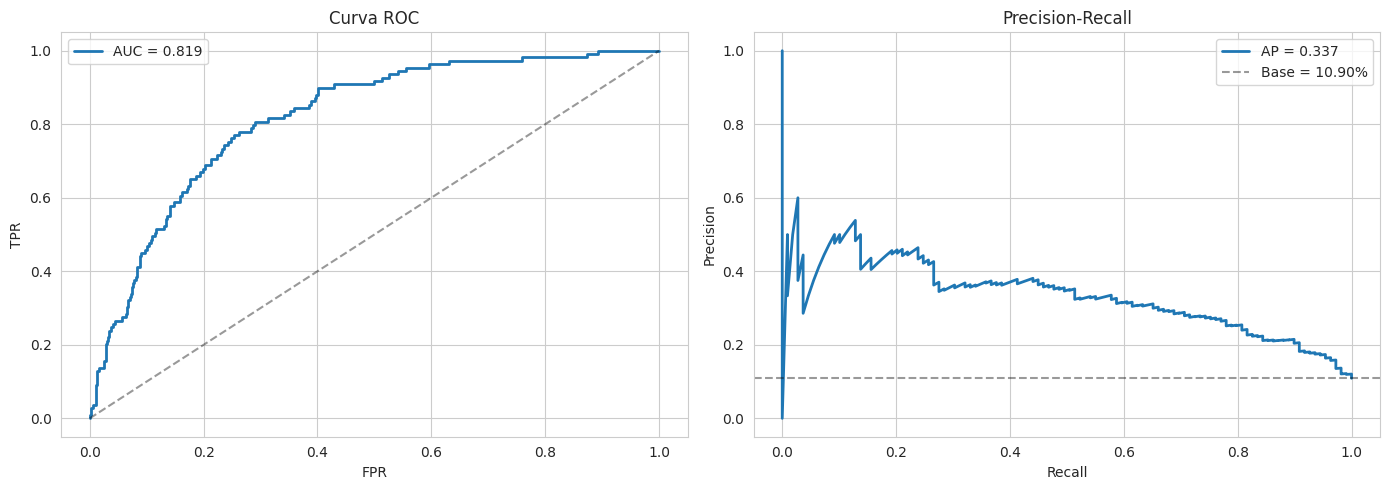

In [19]:
champ_row = df_tuned.iloc[0]
champ_name = f'{champ_row["modelo"]}_{champ_row["balanceamento"]}'
champion = best_models[champ_name]
print(f'🏆 Campeão: {champ_name}')
print(f'   ROC-AUC: {champ_row["ROC_AUC"]:.4f}')
print(f'   KS:      {champ_row["KS"]:.4f}')
print(f'   Top 10%: {champ_row["Top10%"]:.2%}')

if champ_row['modelo'] == 'LogReg':
    sc = StandardScaler()
    X_tr_r, y_tr_r = get_resampled(champ_row['balanceamento'], X_train, y_train)
    sc.fit(X_tr_r)
    proba_test = champion.predict_proba(
        pd.DataFrame(sc.transform(X_test), columns=X_test.columns))[:, 1]
else:
    proba_test = champion.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {champ_row["ROC_AUC"]:.3f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].set(xlabel='FPR', ylabel='TPR', title='Curva ROC')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[1].plot(rec, prec, lw=2, label=f'AP = {champ_row["PR_AUC"]:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4,
                label=f'Base = {y_test.mean():.2%}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall')
axes[1].legend()
plt.tight_layout()
plt.show()

In [20]:
# Tabela de decis (decil 1 = piores 10%)
df_decis = pd.DataFrame({'y': y_test.values, 'proba': proba_test})
df_decis['decil'] = pd.qcut(df_decis['proba'], 10, labels=False, duplicates='drop') + 1
df_decis['decil'] = 11 - df_decis['decil']

tab = df_decis.groupby('decil').agg(
    qtd=('y','size'), fpd=('y','sum'), taxa_fpd=('y','mean'),
    score_min=('proba','min'), score_max=('proba','max')
).round(4)
tab['pct_fpd_acumulado'] = (tab['fpd'].cumsum() / tab['fpd'].sum()).round(4)
tab['lift'] = (tab['taxa_fpd'] / y_test.mean()).round(2)
print('📊 Tabela de decis (decil 1 = 10% piores scores):')
tab

📊 Tabela de decis (decil 1 = 10% piores scores):


,qtd,fpd,taxa_fpd,score_min,score_max,pct_fpd_acumulado,lift
decil,,,,,,,
1,100,36,0.36,0.6768,0.8868,0.3303,3.30
2,100,28,0.28,0.5784,0.6764,0.5872,2.57
3,100,18,0.18,0.4761,0.5780,0.7523,1.65
4,100,8,0.08,0.3845,0.4760,0.8257,0.73
5,100,9,0.09,0.2997,0.3840,0.9083,0.83
6,100,5,0.05,0.2062,0.2989,0.9541,0.46
7,100,2,0.02,0.1378,0.2054,0.9725,0.18
8,100,1,0.01,0.0845,0.1363,0.9817,0.09
9,100,1,0.01,0.0417,0.0839,0.9908,0.09


## 1️⃣6️⃣ Faixas de risco para a política de cobrança

In [21]:
def classificar_faixa(p):
    if p < 0.20:  return 'Baixo'
    if p < 0.45:  return 'Medio'
    if p < 0.70:  return 'Alto'
    return 'Critico'

df_decis['faixa'] = df_decis['proba'].apply(classificar_faixa)
faixa_tab = df_decis.groupby('faixa').agg(
    qtd=('y','size'), fpd=('y','sum'), taxa_fpd=('y','mean')
).reindex(['Baixo','Medio','Alto','Critico']).round(4)
faixa_tab['lift'] = (faixa_tab['taxa_fpd'] / y_test.mean()).round(2)
print('Distribuição de faixas (base de teste):')
faixa_tab

Distribuição de faixas (base de teste):


,qtd,fpd,taxa_fpd,lift
faixa,,,,
Baixo,391,5,0.0128,0.12
Medio,281,19,0.0676,0.62
Alto,243,55,0.2263,2.08
Critico,85,30,0.3529,3.24


## 1️⃣7️⃣ Geração da submissão final

In [23]:
df_sub = pd.read_excel('submissao.xlsx')
print(f'Submissão shape: {df_sub.shape}')

sub_pedido_id = df_sub['pedido_id'].copy()

cols_drop_sub = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df_sub.columns]
df_sub_clean = df_sub.drop(columns=cols_drop_sub)

df_sub_clean['idade'] = df_sub_clean['idade'].apply(fix_idade)
if 'nascimento' in df_sub_clean.columns:
    nasc = pd.to_datetime(df_sub_clean['nascimento'], errors='coerce')
    df_sub_clean['idade'] = df_sub_clean['idade'].fillna((hoje - nasc).dt.days // 365)
    df_sub_clean = df_sub_clean.drop(columns=['nascimento'])

df_sub_clean['data_efetivacao'] = pd.to_datetime(df_sub_clean['data_efetivacao'], errors='coerce')
df_sub_clean['ef_mes'] = df_sub_clean['data_efetivacao'].dt.month
df_sub_clean['ef_dow'] = df_sub_clean['data_efetivacao'].dt.dayofweek
df_sub_clean['ef_dia'] = df_sub_clean['data_efetivacao'].dt.day
df_sub_clean['ef_ano'] = df_sub_clean['data_efetivacao'].dt.year
df_sub_clean = df_sub_clean.drop(columns=['data_efetivacao'])

for c in ['total_financiado','quantidade_parcelas','score']:
    if c in df_sub_clean.columns:
        df_sub_clean[c] = pd.to_numeric(df_sub_clean[c], errors='coerce')

if 'categoria_risco_score' in df_sub_clean.columns:
    df_sub_clean = df_sub_clean.drop(columns=['categoria_risco_score'])
if 'endereco_estado' in df_sub_clean.columns:
    df_sub_clean['endereco_estado'] = df_sub_clean['endereco_estado'].astype(str).str.strip().str.upper().str[:2]

# Frequency encoding: usar mapa do TREINO original
for col in ['produtor','lancamento']:
    if col in df_sub_clean.columns:
        freq = df[col].value_counts(normalize=True)
        df_sub_clean[col+'_freq'] = df_sub_clean[col].map(freq).fillna(0)
        df_sub_clean = df_sub_clean.drop(columns=[col])

cat_cols_sub = [c for c in ['segmento','modalidade','MENSAGEM_TIPO_REGISTRO',
                              'endereco_estado','order_bump'] if c in df_sub_clean.columns]
df_sub_clean = pd.get_dummies(df_sub_clean, columns=cat_cols_sub, drop_first=True, dummy_na=True)
df_sub_clean.columns = [re.sub(r'[^\w]', '_', c) for c in df_sub_clean.columns]

# Alinhar colunas com X_train
for col in X_train.columns:
    if col not in df_sub_clean.columns:
        df_sub_clean[col] = 0
df_sub_clean = df_sub_clean[X_train.columns]

df_sub_clean = pd.DataFrame(imputer.transform(df_sub_clean), columns=df_sub_clean.columns)

if champ_row['modelo'] == 'LogReg':
    sc_sub = StandardScaler()
    X_tr_r, _ = get_resampled(champ_row['balanceamento'], X_train, y_train)
    sc_sub.fit(X_tr_r)
    df_sub_scaled = pd.DataFrame(sc_sub.transform(df_sub_clean), columns=df_sub_clean.columns)
    proba_sub = champion.predict_proba(df_sub_scaled)[:, 1]
else:
    proba_sub = champion.predict_proba(df_sub_clean)[:, 1]

submissao = pd.DataFrame({
    'pedido_id': sub_pedido_id,
    'prob_fpd': proba_sub.round(4),
    'faixa_risco': [classificar_faixa(p) for p in proba_sub]
})
submissao.to_csv('submissao_final.csv', index=False)
print(f'✅ Submissão salva: submissao_final.csv ({len(submissao)} linhas)')
print(f'\nDistribuição de faixas:')
print(submissao['faixa_risco'].value_counts())
submissao.head(10)

Submissão shape: (23354, 56)
✅ Submissão salva: submissao_final.csv (23354 linhas)

Distribuição de faixas:
faixa_risco
Medio    21865
Alto      1414
Baixo       75
Name: count, dtype: int64


,pedido_id,prob_fpd,faixa_risco
0,300988,0.2583,Medio
1,301277,0.3213,Medio
2,431885,0.4094,Medio
3,466590,0.2378,Medio
4,472357,0.4182,Medio
5,481126,0.2800,Medio
6,478489,0.3609,Medio
7,474888,0.2821,Medio
8,475601,0.3887,Medio
9,536323,0.3124,Medio


## 1️⃣8️⃣ Top features (resposta à banca)

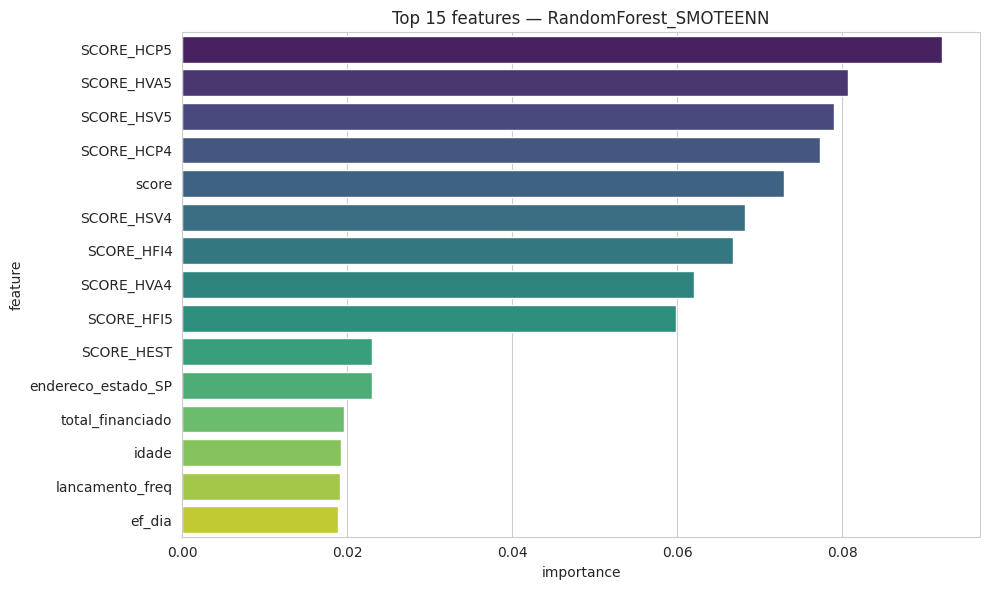

           feature  importance
        SCORE_HCP5    0.092060
        SCORE_HVA5    0.080690
        SCORE_HSV5    0.078940
        SCORE_HCP4    0.077287
             score    0.072865
        SCORE_HSV4    0.068194
        SCORE_HFI4    0.066731
        SCORE_HVA4    0.062025
        SCORE_HFI5    0.059854
        SCORE_HEST    0.023039
endereco_estado_SP    0.023010
  total_financiado    0.019596
             idade    0.019268
   lancamento_freq    0.019118
            ef_dia    0.018915


In [24]:
if hasattr(champion, 'feature_importances_'):
    feat_imp = pd.DataFrame({
        'feature': X_train.columns,
        'importance': champion.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    plt.figure(figsize=(10,6))
    sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 features — {champ_name}')
    plt.tight_layout()
    plt.show()
    print(feat_imp.to_string(index=False))
elif hasattr(champion, 'coef_'):
    feat_imp = pd.DataFrame({
        'feature': X_train.columns,
        'coef': champion.coef_[0]
    })
    feat_imp['abs'] = feat_imp['coef'].abs()
    feat_imp = feat_imp.sort_values('abs', ascending=False).head(15)
    print(feat_imp[['feature','coef']].to_string(index=False))

---

## ✅ Checklist do que este pipeline entrega

- [x] Remoção rigorosa de leakage (15 colunas pós-evento + 10 identificadores)  
- [x] Split **temporal** (não random) — exigência da banca  
- [x] **6 estratégias × 5 modelos = 30 experimentos**  
- [x] Métricas profissionais: ROC-AUC, PR-AUC, **KS**, F1, **top-decil recall**  
- [x] Heatmaps comparativos  
- [x] **Optuna** com 30 trials × 3-fold CV nos top-3  
- [x] Análise por decil com lift  
- [x] Política de cobrança com faixas derivadas do score  
- [x] Submissão `pedido_id, prob_fpd, faixa_risco`  
- [x] Top 15 features  

## 📝 Próximos passos sugeridos

1. **Stacking** dos top-3 modelos (costuma render +0.5 a +1.5pp de ROC-AUC)
2. **Calibração** com `CalibratedClassifierCV` se forem usar a probabilidade como valor de negócio
3. **Walk-forward validation** para checar estabilidade do score em várias safras
4. **Análise por segmento, modalidade e estado** — perguntas explícitas da banca
5. **Análise sem bureau**: rode removendo SCORE_H* — a banca pergunta sobre robustez sem bureau
